In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15,6)

In [257]:
df = pd.read_csv("../data/dataset_after_categorical_imputing.csv")
df.head()

,url,job_title,tech_stack,language_req,is_manager,work_method,contract_type,salary_min,salary_max,exp_years,location,job_level,source,company_name,education_level,is_shift_work
0,https://www.topcv.vn/viec-lam/business-analyst...,Business Analyst,Visio,1,0,Onsite,Full-time,12.0,15.0,1.0,Hà Nội,2,topcv,INVIV CLOUD TECHNOLOGY JOINT STOCK COMPANY,Bachelor,0
1,https://www.topcv.vn/viec-lam/technical-leader...,Technical Leader (PHP/Laravel),"JavaScript, GitHub, REST API, Elasticsearch, I...",0,1,Onsite,Full-time,NaN,NaN,5.0,Hà Nội,3,topcv,CÔNG TY CỔ PHẦN VIETEZ VIỆT NAM,Bachelor,0
2,https://www.topcv.vn/viec-lam/business-analyst...,Business Analyst (Product),"Adobe Illustrator, Visio",1,0,Onsite,Full-time,NaN,NaN,2.0,Hà Nội,2,topcv,VIETTEL IDC,Bachelor,0
3,https://www.topcv.vn/viec-lam/frontend-develop...,Frontend Developer (Web/App IRUKA),"HTML, React, JavaScript, Next.js, Zustand, CSS...",1,0,Onsite,Full-time,NaN,NaN,2.0,Hà Nội,2,topcv,CÔNG TY TNHH THƯƠNG MẠI DỊCH VỤ LIFESTYLE VIỆT...,Bachelor,0
4,https://www.topcv.vn/viec-lam/business-analyst...,Business Analyst (Level Middle Trở Lên),Not Specified,1,0,Onsite,Full-time,20.0,50.0,3.0,Hà Nội,2,topcv,TỔNG CÔNG TY CỔ PHẦN BƯU CHÍNH VIETTEL,Bachelor,0


In [258]:
print("Dataset shape:", df.shape)

Dataset shape: (5661, 16)


In [259]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5661 entries, 0 to 5660
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              5661 non-null   str    
 1   job_title        5661 non-null   str    
 2   tech_stack       5661 non-null   str    
 3   language_req     5661 non-null   int64  
 4   is_manager       5661 non-null   int64  
 5   work_method      5661 non-null   str    
 6   contract_type    5661 non-null   str    
 7   salary_min       2140 non-null   float64
 8   salary_max       2353 non-null   float64
 9   exp_years        5661 non-null   float64
 10  location         5661 non-null   str    
 11  job_level        5661 non-null   int64  
 12  source           5661 non-null   str    
 13  company_name     5661 non-null   str    
 14  education_level  5661 non-null   str    
 15  is_shift_work    5661 non-null   int64  
dtypes: float64(3), int64(4), str(9)
memory usage: 707.8 KB


In [261]:
df.count()

url                5661
job_title          5661
tech_stack         5661
language_req       5661
is_manager         5661
work_method        5661
contract_type      5661
salary_min         2140
salary_max         2353
exp_years          5661
location           5661
job_level          5661
source             5661
company_name       5661
education_level    5661
is_shift_work      5661
dtype: int64

In [262]:
print("Salary statistics:")
salary_stats = df[['salary_min','salary_max']].describe()

salary_stats = salary_stats.drop('count')

salary_stats

Salary statistics:


,salary_min,salary_max
mean,18.973640,31.433923
std,19.828593,30.246911
min,0.250000,0.380000
25%,10.000000,15.000000
50%,15.000000,25.000000
75%,25.000000,40.000000
max,500.000000,800.000000


In [213]:
df.isnull().sum()

url                   0
job_title             0
tech_stack            0
language_req          0
is_manager            0
work_method           0
contract_type         0
salary_min         3521
salary_max         3308
exp_years             0
location              0
job_level             0
source                0
company_name          0
education_level       0
is_shift_work         0
dtype: int64

In [214]:
df = df.dropna(subset=["salary_min", "salary_max", "exp_years"])

print("New dataset shape:", df.shape)

New dataset shape: (2094, 16)


In [263]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [215]:
df["salary"] = (df["salary_min"] + df["salary_max"]) / 2

In [216]:
df[["salary_min","salary_max","salary"]].head()


,salary_min,salary_max,salary
0,12.0,15.0,13.5
4,20.0,50.0,35.0
5,10.0,15.0,12.5
6,30.0,40.0,35.0
9,10.0,15.0,12.5


### Insight

Job postings often provide salary information as a range (salary_min and salary_max).
To simplify the analysis, we calculate the average salary for each job posting.

The new variable 'salary' represents the midpoint of the salary range and serves as
an estimate of the typical compensation offered for that position.

This allows us to analyze salary distribution and compare salaries across cities
and experience levels more effectively.

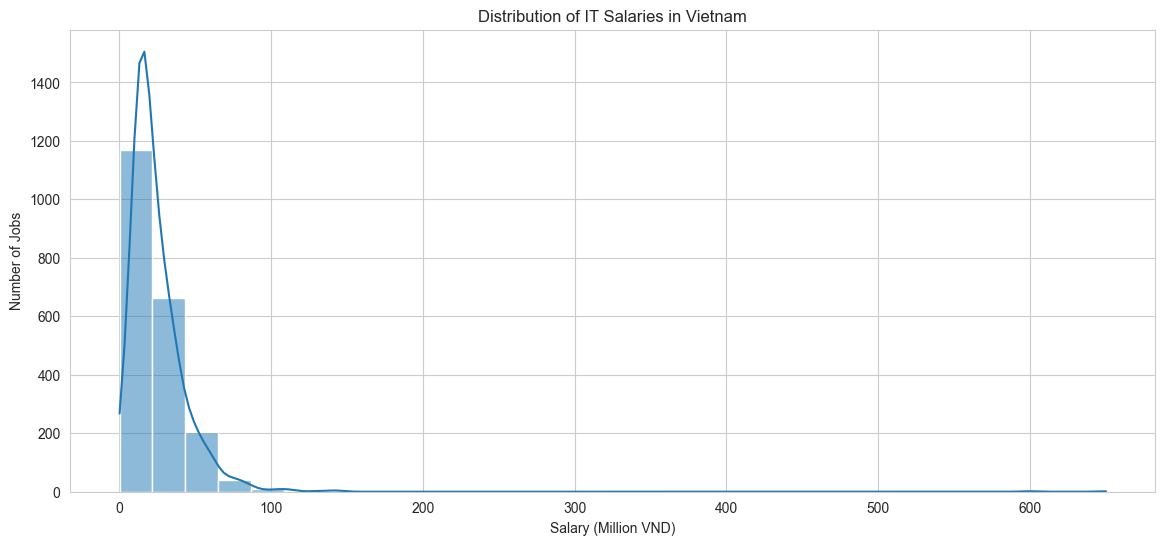

In [217]:
plt.figure(figsize=(14,6))

sns.histplot(df["salary"], bins=30, kde=True)

plt.title("Distribution of IT Salaries in Vietnam")
plt.xlabel("Salary (Million VND)")
plt.ylabel("Number of Jobs")

plt.show()

### Insight

- Most IT salaries in Vietnam fall between **15–40 million VND**. 
- The salary distribution appears to be right-skewed, meaning most job postings fall within the lower to mid salary range, while only a small proportion of positions offer very high salaries. 
- This suggests that the majority of roles in the dataset are likely entry-level or mid-level positions, while high-paying senior roles are less common.

In [ ]:
df["location"].unique()

In [219]:
def clean_city(x):
    if pd.isna(x):
        return None
    if "Hà Nội" in x:
        return "Hà Nội"
    elif "Hồ Chí Minh" in x:
        return "Hồ Chí Minh"
    elif "Đà Nẵng" in x:
        return "Đà Nẵng"
    else:
        return None

df["city_clean"] = df["location"].apply(clean_city)

In [220]:
df_city = df[df["city_clean"].notna()]

In [238]:
df_city["city_clean"].value_counts()

city_clean
Hà Nội         1180
Hồ Chí Minh     701
Đà Nẵng          41
Name: count, dtype: int64

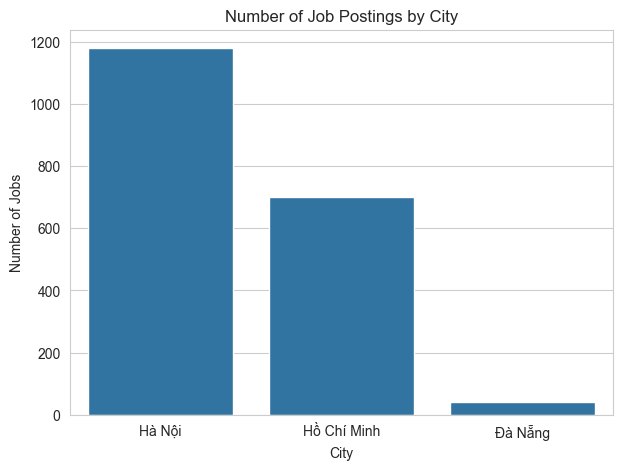

In [239]:
plt.figure(figsize=(7,5))

sns.countplot(data=df_city, x="city_clean")

plt.title("Number of Job Postings by City")
plt.xlabel("City")
plt.ylabel("Number of Jobs")

plt.show()

### Insight
The salary comparison across cities should be interpreted cautiously because the number of job postings in Da Nang is relatively small compared to Ho Chi Minh City and Hanoi.

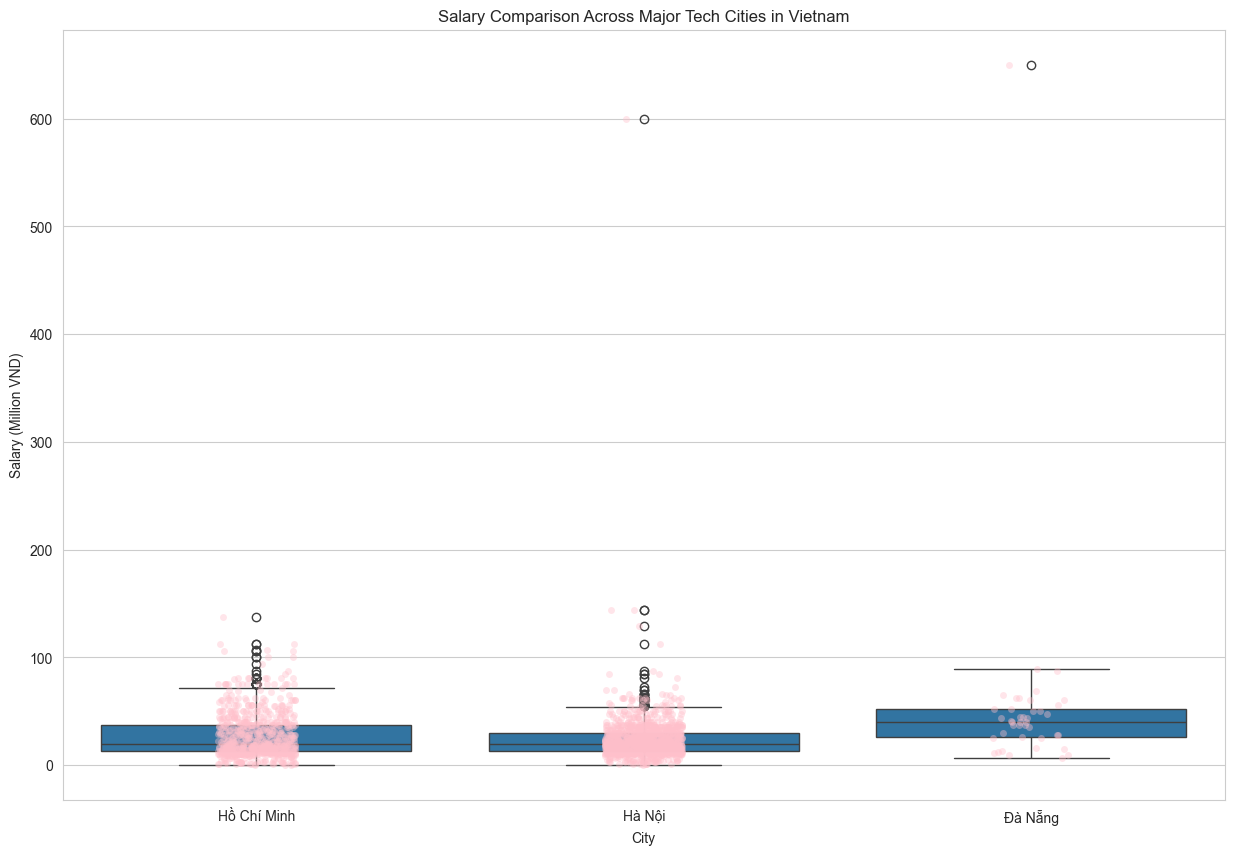

In [240]:
plt.figure(figsize=(15,10))
order = ["Hồ Chí Minh","Hà Nội","Đà Nẵng"]

sns.boxplot(x="city_clean", y="salary", data=df_city, order=order )

sns.stripplot(x="city_clean", y="salary", data=df_city, color="pink", alpha=0.4)

plt.title("Salary Comparison Across Major Tech Cities in Vietnam")
plt.xlabel("City")
plt.ylabel("Salary (Million VND)")

plt.show()

### Insight
The boxplot compares salary distributions across Ho Chi Minh City, Hanoi, and Da Nang.
From the boxplot we observe:

- Salaries in **Ho Chi Minh City** tend to have a slightly higher median.
- **Ha Noi** shows a wide salary distribution with several high outliers.
- **Da Nang** appears to have fewer extreme values but still contains some very high salaries.

This suggests that the two largest tech hubs (Ha Noi and Ho Chi Minh City) offer more varied salary ranges.

## Experience vs Salary
We analyze the relationship between years of experience and salary to understand whether more experience is associated with higher salaries.

In [241]:
corr = df["exp_years"].corr(df["salary"])
print("Correlation between experience and salary:", corr)

Correlation between experience and salary: 0.09922766595830648


### Insight
The correlation is weak (~0.x)
This suggests experience alone is not a strong predictor of salary.
Other factors such as technical skills, company size, or job specialization may play a larger role in determining salary.

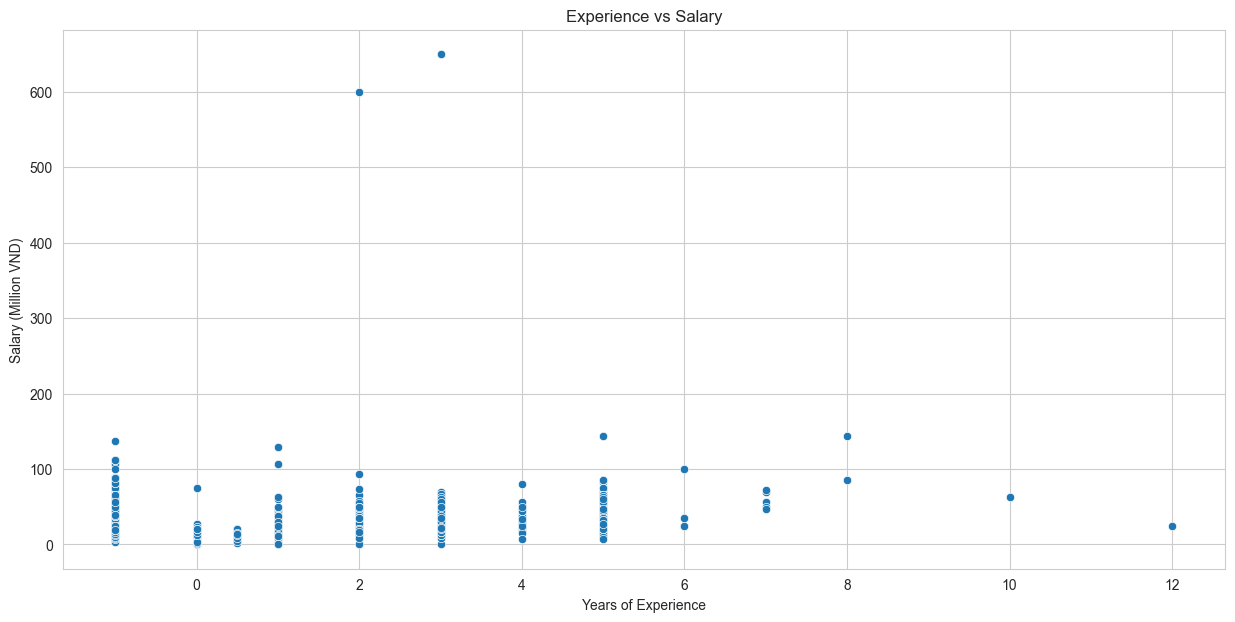

In [242]:
plt.figure(figsize=(15,7))

sns.scatterplot(x="exp_years", y="salary", data=df)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (Million VND)")

plt.show()

### Insight
There is a positive relationship between years of experience and salary, indicating that more experienced candidates tend to receive higher salaries.

However, the relationship is not perfectly linear, suggesting that other factors such as technical skills, company size, or job specialization may also influence salary levels.

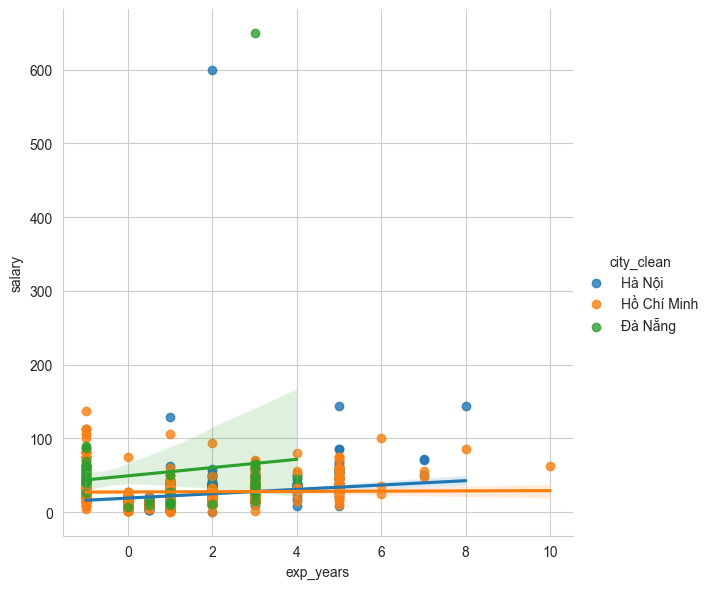

In [243]:
sns.lmplot(
    x="exp_years",
    y="salary",
    hue="city_clean",
    data=df_city,
    height=6
    
)

### Insight 
The regression lines indicate a general upward trend between experience and salary across all major cities.

While the positive trend is consistent, salary levels vary slightly between cities, potentially reflecting differences in demand, cost of living,  or concentration of technology companies.

In [244]:
for col in ['salary_min','salary_max']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("Column:", col)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))
    print("----------")

Column: salary_min
Lower bound: -12.5
Upper bound: 47.5
Number of outliers: 98
----------
Column: salary_max
Lower bound: -22.5
Upper bound: 77.5
Number of outliers: 70
----------


In [245]:
outliers[['salary_min','salary_max','job_title','company_name', 'url']].head()


,salary_min,salary_max,job_title,company_name,url
107,50.0,90.0,Lead Full-Stack Developer – Up To 90M+,CÔNG TY TNHH MONIVA VIETNAM,https://www.topcv.vn/viec-lam/lead-full-stack-...
125,60.0,90.0,Lead Mobile Developer (High Salary 60–90M),CÔNG TY TNHH MONIVA VIETNAM,https://www.topcv.vn/viec-lam/lead-mobile-deve...
577,65.2,81.5,(JP 223) Kỹ Sư Lập Trình Vận Hành Máy Gia Công...,CTY TNHH R TECHNO VIỆT NAM,https://www.topcv.vn/viec-lam/jp-223-ky-su-lap...
819,40.0,80.0,Solution Architect,CÔNG TY CỔ PHẦN TẬP ĐOÀN MEEY LAND,https://careerviet.vn/vi/tim-viec-lam/solution...
937,60.0,80.0,Giám đốc Sản phẩm (Product Director),CÔNG TY CỔ PHẦN TẬP ĐOÀN MEEY LAND,https://careerviet.vn/vi/tim-viec-lam/giam-doc...


In [246]:
print("Number of outliers:", len(outliers))

Number of outliers: 70


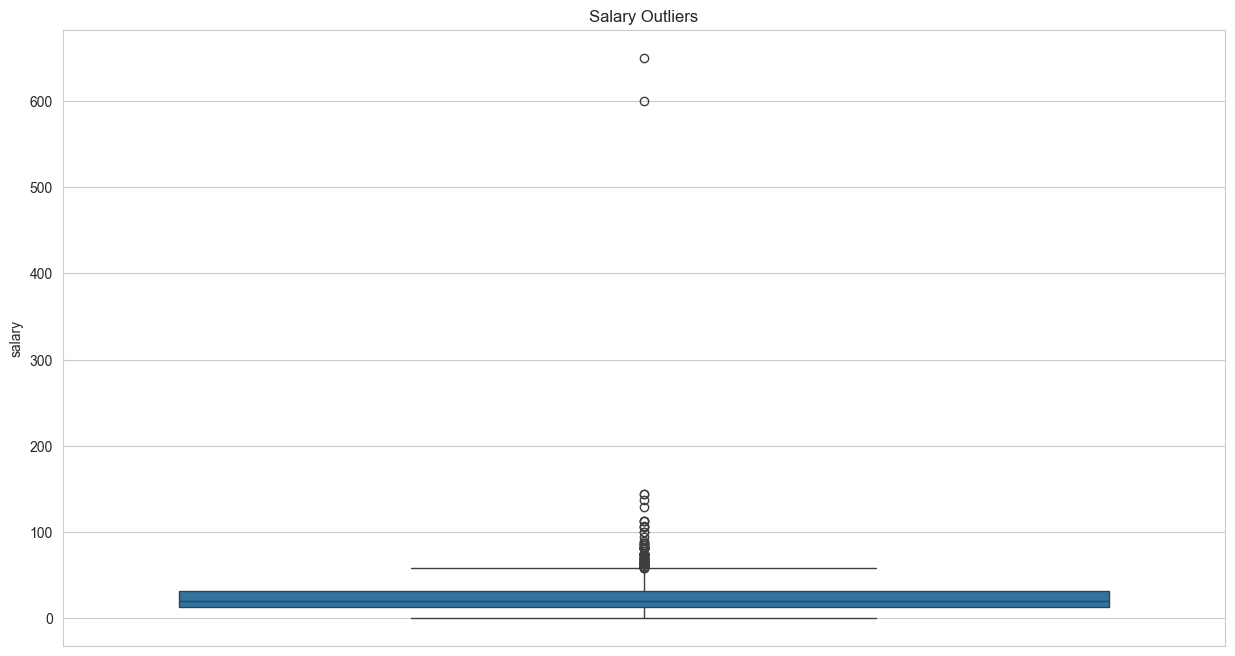

In [231]:
plt.figure(figsize=(15,8))

sns.boxplot(y=df["salary"])

plt.title("Salary Outliers")

plt.show()

### Key Insights

1. Most IT salaries in Vietnam fall between **15–40 million VND**.
2. Ho Chi Minh City and Hanoi dominate the IT job market.
3. Salary tends to increase with years of experience.
4. Some high salary outliers exist, likely representing senior or specialized roles.
5. Salary distributions vary slightly across cities, but sample size differences should be considered when interpreting the results.